# TCGA-OV 3-year mortality classifier

Binary companion to `ovarian-os-lasso-cox.ipynb`: predict **death within 3
years** from tumor gene expression plus age, FIGO stage, and residual disease.

Patients censored before 3 years are dropped — their 3-year status is
unknowable. Expect ~80 of 303 dropped, ~220 evaluable.

| Model | Features |
|---|---|
| clinical LR (baseline) | age, stage, residual |
| expr ENET | top-500 variance genes, elastic-net logistic |
| expr+clin ENET | genes + clinical |
| expr+clin HGB | genes + clinical, gradient boosting |

The bar to beat is the clinical baseline's out-of-fold ROC AUC. Gene
selection and scaling happen **inside each CV fold**. External check on
GSE26712 / GSE14764 with the genes-only model — GEO cohorts have no clinical
covariates.

**Before running**

1. Locally: `.venv/bin/python agent/scripts/colab_check.py --dataset tcga-ov-xena-rna-seq-hiseqv2 --dataset tcga-ov-xena-clinical-matrix --dataset gse26712-ovarian-expression-series-matrix --dataset gse14764-ovarian-expression-series-matrix`
2. In Cursor: *Select Kernel* → *Colab* → *New Colab Server* (CPU is enough).
3. Private repo: Colab secret `GITHUB_TOKEN` with notebook access on.

## 1. Bootstrap

Puts this repo on the runtime and imports `colab_env`. Same cell as the smoke
test — shallow, blobless, sparse clone, then datasets are fetched on demand.

In [1]:
# Mirrors .research/config.yaml -> colab
REPO, BRANCH, DEST = "github.com/XooTB/research.git", "main", "/content/research"
SPARSE = ["agent", ".research", "docs", "notebooks"]
TOKEN_SECRET = "GITHUB_TOKEN"

import importlib
import pathlib
import subprocess
import sys


def on_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


if on_colab():
    token = ""
    try:
        from google.colab import userdata
        token = userdata.get(TOKEN_SECRET) or ""
    except Exception:
        pass  # public repo, or the secret isn't shared with this notebook

    url = f"https://{token + '@' if token else ''}{REPO}"
    dest = pathlib.Path(DEST)
    if not (dest / ".git").exists():
        try:
            subprocess.run(["git", "clone", "--depth", "1", "--filter=blob:none",
                            "--sparse", "--branch", BRANCH, url, DEST],
                           check=True, capture_output=True, text=True)
        except subprocess.CalledProcessError as exc:
            detail = exc.stderr.replace(token, "***") if token else exc.stderr
            raise SystemExit(
                "clone failed. If the repo is private, add a PAT as the Colab "
                f"secret {TOKEN_SECRET!r} and enable notebook access.\n{detail}"
            ) from None
        subprocess.run(["git", "-C", DEST, "sparse-checkout", "set", *SPARSE], check=True)
    else:
        # Leftover clone from an earlier session. Force it onto origin so a
        # dirty tree or a cached import cannot hide newly pushed helpers.
        subprocess.run(["git", "-C", DEST, "remote", "set-url", "origin", url], check=False)
        subprocess.run(["git", "-C", DEST, "fetch", "origin", BRANCH], check=True)
        subprocess.run(["git", "-C", DEST, "reset", "--hard", f"origin/{BRANCH}"], check=True)
        subprocess.run(["git", "-C", DEST, "sparse-checkout", "set", *SPARSE], check=False)
    root = dest
else:
    root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
                if (p / "agent" / "scripts" / "colab_env.py").exists())

sys.path.insert(0, str(root / "agent" / "scripts"))
import colab_env as ce
importlib.reload(ce)

head = subprocess.run(["git", "-C", str(root), "rev-parse", "--short", "HEAD"],
                      capture_output=True, text=True, check=False).stdout.strip()
print(ce.summary())
print(f"git {head}")

Colab runtime · Python 3.13.15
Accelerator : none (CPU only) — pick a GPU runtime in the kernel selector
CPU / RAM   : 2 cores, 13.6 GB
Disk free   : 94.1 GB
Workspace   : /content/research
git 9ad5275


## 2. Dependencies

Colab already has pandas / sklearn / matplotlib. `lifelines` comes from
`agent/requirements-colab.txt` (Kaplan–Meier for the predicted risk groups).

In [2]:
print(ce.require("pandas", "numpy", "scikit-learn", "matplotlib", "lifelines"))
print(ce.install_requirements())

{'installed': ['lifelines'], 'already_present': ['pandas', 'numpy', 'scikit-learn', 'matplotlib']}
{'installed_from': '/content/research/agent/requirements-colab.txt'}


## 3. Load TCGA-OV and build the 3-year label

`tcga_os` joins HiSeqV2 to the clinical matrix (primary tumours only, OS in
days). The label is `dead within 3 years`; patients alive but censored before
3 years are excluded from every metric below. That exclusion biases the
sample slightly toward worse-prognosis patients — it's the standard
trade-off for a binary survival-horizon task without survival-specific
classifiers.

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold

HORIZON = 365.25 * 3

X, time, event, clin, meta = ce.tcga_os()

evalable = ~((event == 0) & (time < HORIZON))
y = ((event == 1) & (time <= HORIZON)).astype(int)

Xe, t_ev, e_ev, ye = X[evalable], time[evalable], event[evalable], y[evalable]
cline = clin.loc[evalable]

print(meta)
print(f"evaluable: {len(ye)} of {len(y)} "
      f"(dropped {int((~evalable).sum())} censored before 3y)")
print(f"positives (dead within 3y): {int(ye.sum())} ({ye.mean():.1%})")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

{'dataset': 'tcga-ov-xena-rna-seq-hiseqv2', 'clinical': 'tcga-ov-xena-clinical-matrix', 'n_samples': 303, 'n_features': 20530, 'n_events': 182, 'n_censored': 121, 'median_followup_days': 951.0, 'dropped_nonprimary': 4}
evaluable: 223 of 303 (dropped 80 censored before 3y)
positives (dead within 3y): 95 (42.6%)


## 4. Clinical-only baseline

Logistic regression on age, stage, residual disease — same encoding as the
Cox baseline in `ovarian-os-lasso-cox.ipynb`. This is the number every
expression model must beat. Median imputation is fit on the training fold
only.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

STAGE = {"I": 1, "IA": 1, "IB": 1, "IC": 1,
         "II": 2, "IIA": 2, "IIB": 2, "IIC": 2,
         "III": 3, "IIIA": 3, "IIIB": 3, "IIIC": 3,
         "IV": 4, "IVA": 4, "IVB": 4}
RESIDUAL = {"NO MACROSCOPIC DISEASE": 0, "1-10 MM": 1, "11-20 MM": 2, ">20 MM": 3}


def _stage(val):
    t = str(val).upper().replace("STAGE", "").strip()
    return STAGE.get(t)


def _residual(val):
    return RESIDUAL.get(str(val).strip().upper())


clin_X = pd.DataFrame({
    "age": pd.to_numeric(cline["age_at_initial_pathologic_diagnosis"], errors="coerce"),
    "stage": cline["clinical_stage"].map(_stage),
    "residual": cline["tumor_residual_disease"].map(_residual),
}, index=cline.index)


def impute(train, test):
    tr, te = train.copy(), test.copy()
    for c in tr.columns:
        med = tr[c].median()
        tr[c] = tr[c].fillna(med)
        te[c] = te[c].fillna(med)
    return tr, te


def oof_clinical():
    prob = pd.Series(index=clin_X.index, dtype=float)
    for tr, te in cv.split(clin_X, ye):
        Ctr, Cte = impute(clin_X.iloc[tr], clin_X.iloc[te])
        sc = StandardScaler()
        m = LogisticRegression(max_iter=2000)
        m.fit(sc.fit_transform(Ctr), ye.iloc[tr])
        prob.iloc[te] = m.predict_proba(sc.transform(Cte))[:, 1]
    return prob


base_prob = oof_clinical()

## 5. Expression classifiers

Variance-filter to 500 genes **inside each fold**, z-score on the training
fold, optionally append the (imputed, scaled) clinical covariates. Two
learners: elastic-net logistic regression (`saga`) and histogram gradient
boosting. Everything is compared on out-of-fold predicted probabilities from
the same 5 splits.

In [5]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

N_GENES = 500


def top_var(X, k):
    return X.var(axis=0).nlargest(min(k, X.shape[1])).index


def oof_expr(make_model, n_genes=N_GENES, use_clinical=True):
    prob = pd.Series(index=Xe.index, dtype=float)
    for tr, te in cv.split(Xe, ye):
        cols = top_var(Xe.iloc[tr], n_genes)
        gsc = StandardScaler()
        Ztr = pd.DataFrame(gsc.fit_transform(Xe.iloc[tr][cols]),
                           index=Xe.index[tr], columns=cols)
        Zte = pd.DataFrame(gsc.transform(Xe.iloc[te][cols]),
                           index=Xe.index[te], columns=cols)
        if use_clinical:
            Ctr, Cte = impute(clin_X.iloc[tr], clin_X.iloc[te])
            csc = StandardScaler()
            Ztr = Ztr.join(pd.DataFrame(csc.fit_transform(Ctr),
                                        index=Ctr.index, columns=Ctr.columns))
            Zte = Zte.join(pd.DataFrame(csc.transform(Cte),
                                        index=Cte.index, columns=Cte.columns))
        m = make_model()
        m.fit(Ztr, ye.iloc[tr])
        prob.iloc[te] = m.predict_proba(Zte)[:, 1]
    return prob


def enet():
    return LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=0.5,
                              C=0.1, max_iter=5000, random_state=0)


def hgb():
    return HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05,
                                          max_leaf_nodes=15,
                                          l2_regularization=1.0, random_state=0)


results = {"clinical LR (baseline)": base_prob}
results["expr ENET"] = oof_expr(enet, use_clinical=False)
results["expr+clin ENET"] = oof_expr(enet, use_clinical=True)
results["expr+clin HGB"] = oof_expr(hgb, use_clinical=True)

summary = pd.DataFrame([
    {"model": name,
     "oof_auc": roc_auc_score(ye, p),
     "oof_avg_precision": average_precision_score(ye, p)}
    for name, p in results.items()
]).set_index("model").sort_values("oof_auc", ascending=False)
print(summary.round(3))

best_name = summary.index[0]
best_prob = results[best_name]
print(f"\nbest: {best_name}  OOF AUC={summary.iloc[0]['oof_auc']:.3f} "
      f"vs baseline {summary.loc['clinical LR (baseline)', 'oof_auc']:.3f}")

                        oof_auc  oof_avg_precision
model                                             
expr+clin ENET            0.695              0.632
expr ENET                 0.681              0.607
clinical LR (baseline)    0.646              0.574
expr+clin HGB             0.638              0.587

best: expr+clin ENET  OOF AUC=0.695 vs baseline 0.646


## 6. Threshold, confusion matrix, Kaplan–Meier

The cut is the Youden point of the **out-of-fold** ROC, so it is not tuned on
the samples it is evaluated on. The KM curve splits patients by the predicted
class — a reality check that the binary score still orders survival.

threshold (Youden): 0.417
[[82 46]
 [27 68]]
sensitivity=0.716  specificity=0.641


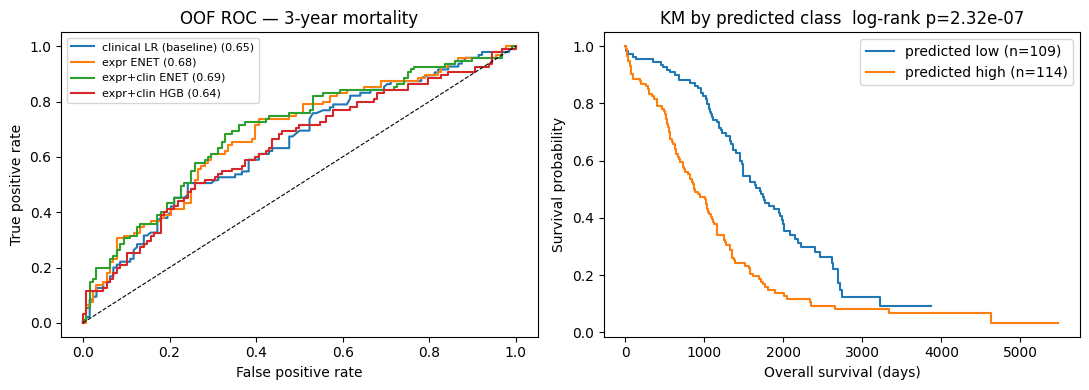

In [6]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from sklearn.metrics import confusion_matrix, roc_curve

fpr, tpr, thr = roc_curve(ye, best_prob)
cut = float(thr[np.argmax(tpr - fpr)])
pred = (best_prob >= cut).astype(int)
cm = confusion_matrix(ye, pred)
tn, fp, fn, tp = cm.ravel()
print(f"threshold (Youden): {cut:.3f}")
print(cm)
print(f"sensitivity={tp / (tp + fn):.3f}  specificity={tn / (tn + fp):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, p in results.items():
    f, t, _ = roc_curve(ye, p)
    axes[0].plot(f, t, label=f"{name} ({roc_auc_score(ye, p):.2f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("OOF ROC — 3-year mortality")
axes[0].legend(fontsize=8)

km = KaplanMeierFitter()
for label, mask in [("predicted low", pred == 0), ("predicted high", pred == 1)]:
    km.fit(t_ev[mask], e_ev[mask], label=f"{label} (n={int(mask.sum())})")
    km.plot(ax=axes[1], ci_show=False)
lr = logrank_test(t_ev[pred == 1], t_ev[pred == 0], e_ev[pred == 1], e_ev[pred == 0])
axes[1].set_xlabel("Overall survival (days)")
axes[1].set_ylabel("Survival probability")
axes[1].set_title(f"KM by predicted class  log-rank p={lr.p_value:.3g}")
plt.tight_layout()
plt.show()

## 7. External validation (GSE26712, GSE14764)

The genes-only elastic-net is refit on all evaluable TCGA samples and scored
on the two Affymetrix cohorts after a within-cohort z-score (same caveat as
the LASSO-Cox notebook: RNA-seq and microarray scales are only roughly
comparable, and the logistic intercept does not transfer — AUC is
rank-based, so that's fine). Each cohort gets its own 3-year label from its
own follow-up; GSE26712's 10 normal HOSE samples are dropped.

In [7]:
cols_full = top_var(Xe, N_GENES)
gsc_full = StandardScaler()
Z_full = pd.DataFrame(gsc_full.fit_transform(Xe[cols_full]),
                      index=Xe.index, columns=cols_full)
final_model = enet()
final_model.fit(Z_full, ye)
coef = pd.Series(final_model.coef_.ravel(), index=cols_full)
nz = coef[coef.abs() > 1e-8].sort_values(key=np.abs, ascending=False)
print(f"non-zero genes in final model: {len(nz)}")
print(nz.head(15).to_string())

probe_to_gene = ce.gpl_gene_map("GPL96")


def eval_geo_classifier(slug, *, tumor_col, tumor_val, time_col, event_col,
                        time_scale, event_positive=None):
    expr, pheno = ce.load_geo(slug)
    keep = (pheno[tumor_col].astype(str).eq(tumor_val) if tumor_col
            else pd.Series(True, index=pheno.index))
    samples = expr.columns.intersection(pheno.index[keep])
    Xg = ce.collapse_to_genes(expr[samples].T, probe_to_gene)
    t = pd.to_numeric(pheno.loc[samples, time_col], errors="coerce") * time_scale
    if event_positive is None:
        e = pd.to_numeric(pheno.loc[samples, event_col], errors="coerce")
    else:
        e = pheno.loc[samples, event_col].astype(str).str.startswith(event_positive).astype(float)
    ok = t.notna() & e.notna() & (t >= 1)
    t, e, Xg = t[ok], e[ok].astype(int), Xg.loc[ok]
    mask = ~((e == 0) & (t < HORIZON))
    yg = ((e == 1) & (t <= HORIZON)).astype(int)
    common = coef.index.intersection(Xg.columns)
    Z = Xg.loc[mask, common]
    Z = (Z - Z.mean(axis=0)) / Z.std(axis=0, ddof=0).replace(0, np.nan)
    score = Z.fillna(0) @ coef.loc[common]
    out = {
        "dataset": slug,
        "n_evaluable": int(mask.sum()),
        "n_dead_3y": int(yg[mask].sum()),
        "n_genes_present": int(len(common)),
        "auc_3y": float(roc_auc_score(yg[mask], score)),
    }
    print(out)
    return out


ext_bonome = eval_geo_classifier(
    "gse26712-ovarian-expression-series-matrix",
    tumor_col="source_name_ch1", tumor_val="Ovarian tumor",
    time_col="survival years", event_col="status",
    time_scale=365.25, event_positive="DOD",
)
ext_cnb = eval_geo_classifier(
    "gse14764-ovarian-expression-series-matrix",
    tumor_col=None, tumor_val="",
    time_col="overall survival time", event_col="overall survival event",
    time_scale=30.437, event_positive=None,
)

non-zero genes in final model: 88
sample
OVGP1      -0.320967
SOSTDC1    -0.276010
PI3         0.273924
CLDN10     -0.259526
HLA-DRB6   -0.256568
MMP1       -0.227307
OBP2B       0.204063
BCHE        0.196273
TOX3       -0.179032
ACCN1       0.175307
KRT5       -0.173892
NCCRP1      0.169131
RELN        0.160555
CTAG1B      0.153723
NPY         0.150239
{'dataset': 'gse26712-ovarian-expression-series-matrix', 'n_evaluable': 169, 'n_dead_3y': 74, 'n_genes_present': 321, 'auc_3y': 0.614651493598862}
{'dataset': 'gse14764-ovarian-expression-series-matrix', 'n_evaluable': 48, 'n_dead_3y': 13, 'n_genes_present': 321, 'auc_3y': 0.5054945054945055}


## 8. Save the run

Prints the record between markers so it can be harvested from this notebook's
saved output after you **save the file**:

```bash
.venv/bin/python agent/scripts/colab_runs.py --import-notebook notebooks/ovarian-3yr-mortality-classifier.ipynb
.venv/bin/python agent/scripts/colab_runs.py --last
```

In [8]:
payload = {
    "task": "tcga-ov 3-year mortality classifier",
    "horizon_days": HORIZON,
    "train": meta,
    "n_evaluable": int(len(ye)),
    "n_dropped_censored": int((~evalable).sum()),
    "prevalence_3y": float(ye.mean()),
    "models": {name: {"oof_auc": float(roc_auc_score(ye, p)),
                      "oof_avg_precision": float(average_precision_score(ye, p))}
               for name, p in results.items()},
    "best_model": best_name,
    "threshold_youden": cut,
    "sensitivity": float(tp / (tp + fn)),
    "specificity": float(tn / (tn + fp)),
    "confusion": cm.tolist(),
    "km_logrank_p": float(lr.p_value),
    "signature_top": {k: float(v) for k, v in nz.head(20).items()},
    "external": {"gse26712": ext_bonome, "gse14764": ext_cnb},
}
run_dir = ce.save_run("tcga-ov-3yr-mortality-clf", payload)
print(run_dir)

print("===RUN-RECORD-BEGIN===")
print((run_dir / "run.json").read_text().strip())
print("===RUN-RECORD-END===")
print(ce.push_runs())

/content/research/.research/colab/runs/20260825T034757Z-tcga-ov-3yr-mortality-clf
===RUN-RECORD-BEGIN===
{
  "name": "tcga-ov-3yr-mortality-clf",
  "saved_at": "20260825T034757Z",
  "env": {
    "colab": true,
    "python": "3.13.15",
    "workspace": "/content/research",
    "workspace_present": true,
    "cpu_count": 2,
    "ram_gb": 13.6,
    "disk_free_gb": 93.8,
    "gpu": {
      "available": false,
      "name": null,
      "memory_mb": null,
      "driver": null,
      "torch_cuda": false,
      "torch_version": "2.11.0+cpu"
    }
  },
  "result": {
    "task": "tcga-ov 3-year mortality classifier",
    "horizon_days": 1095.75,
    "train": {
      "dataset": "tcga-ov-xena-rna-seq-hiseqv2",
      "clinical": "tcga-ov-xena-clinical-matrix",
      "n_samples": 303,
      "n_features": 20530,
      "n_events": 182,
      "n_censored": 121,
      "median_followup_days": 951.0,
      "dropped_nonprimary": 4
    },
    "n_evaluable": 223,
    "n_dropped_censored": 80,
    "prevalence